<a href="https://colab.research.google.com/github/Shaikh-Uzair-Ahmed/1BM23CS307/blob/ML/1BM23CS307_LAB6_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  PART 1 : SVM Classifier — IRIS Dataset
Shape   : (150, 5)
Columns : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
Classes : ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Train : 120  |  Test : 30

  Kernel   : RBF
  Accuracy : 0.9667  (96.67%)
  Confusion Matrix :
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

  Kernel   : LINEAR
  Accuracy : 1.0000  (100.00%)
  Confusion Matrix :
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]



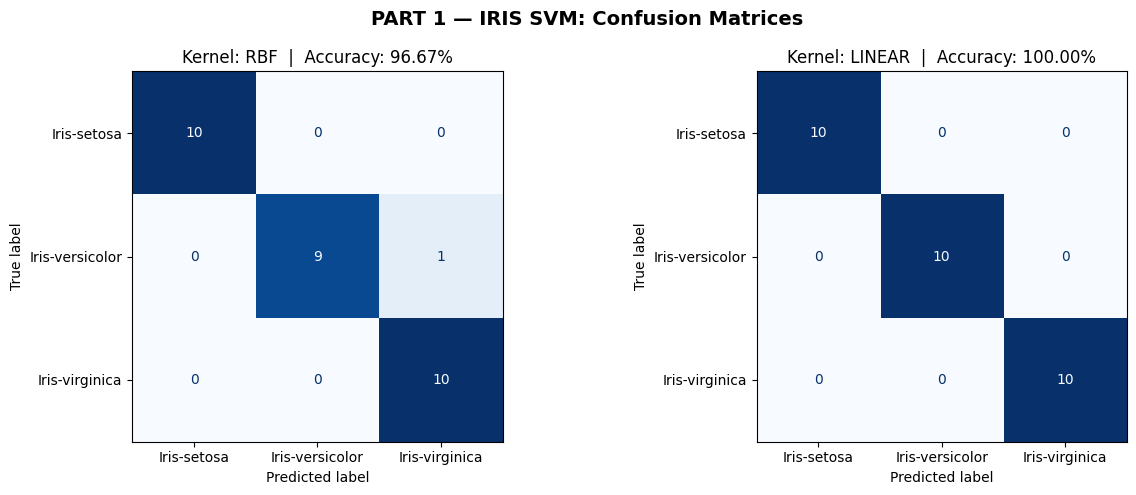

----------------------------------------
IRIS KERNEL COMPARISON
      RBF : 96.67%
   LINEAR : 100.00%
  Better kernel : LINEAR

  PART 2 : SVM Classifier — Letter Recognition Dataset
Shape     : (20000, 17)
Columns   : ['xbox ', 'ybox ', 'width ', 'height', 'onpix ', 'xbar ', 'ybar ', 'x2bar', 'y2bar ', 'xybar ', 'x2ybar', 'xy2bar', 'xedge ', 'xedgey', 'yedge ', 'yedgex', 'letter']
Classes   : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Class distribution:
letter
A    789
B    766
C    736
D    805
E    768
F    775
G    773
H    734
I    755
J    747
K    739
L    761
M    792
N    783
O    753
P    803
Q    783
R    758
S    748
T    796
U    813
V    764
W    752
X    787
Y    786
Z    734

Train : 16000  |  Test : 4000

Training SVM (RBF, C=10, gamma='scale') … may take 1–2 min on full data
Training complete.

  Kernel   : RBF  (C=10, gamma='scale')
  Accuracy : 0.9748  (97.47%)

  Confusion Mat

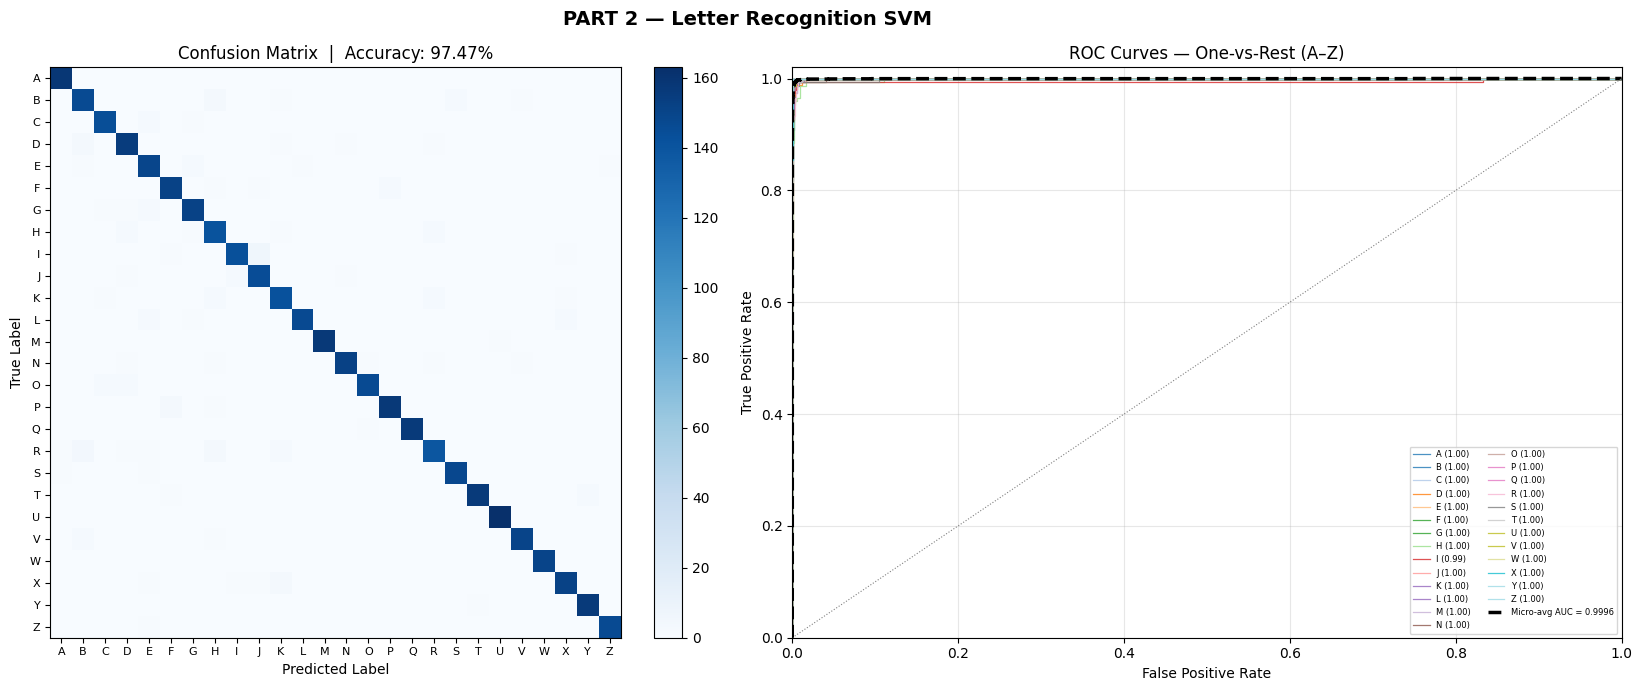

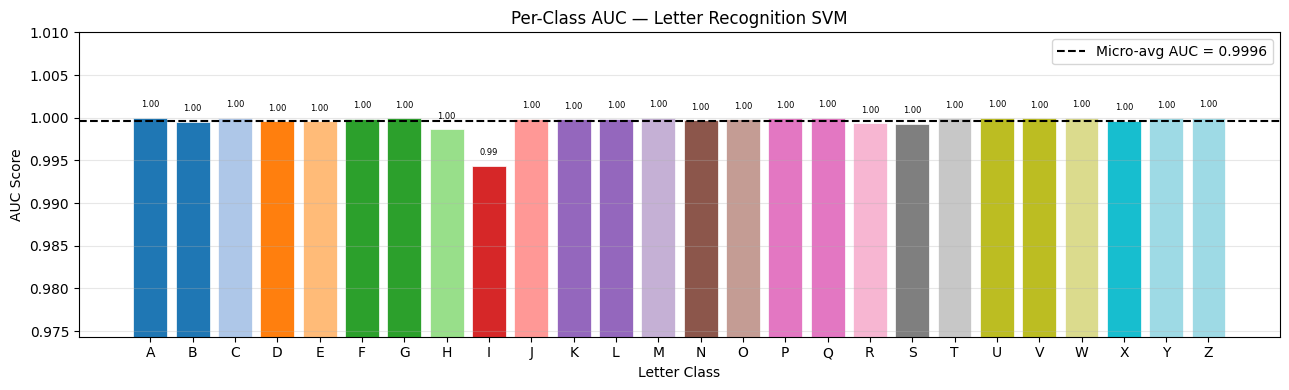


  FINAL SUMMARY
  IRIS  — RBF    kernel     : 96.67%
  IRIS  — Linear kernel     : 100.00%
  Letter Recog. — RBF       : 97.47%
  Letter Recog. — Micro AUC : 0.9996

Saved plots:
  → iris_svm_confusion.png
  → letter_svm_roc.png
  → letter_auc_bar.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize, StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

# ══════════════════════════════════════════════════════════════════════════════
#  PART 1 — SVM on IRIS dataset  (RBF and Linear kernels)
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 65)
print("  PART 1 : SVM Classifier — IRIS Dataset")
print("=" * 65)

try:
    iris = pd.read_csv('iris.csv')
except FileNotFoundError:
    print("Error: 'iris.csv' not found.")
    raise

print(f"Shape   : {iris.shape}")
print(f"Columns : {list(iris.columns)}")
print(f"Classes : {iris.iloc[:, -1].unique()}\n")

X_iris = iris.iloc[:, :-1].values
y_iris = iris.iloc[:, -1].values

le_iris   = LabelEncoder()
y_iris    = le_iris.fit_transform(y_iris)

scaler_iris = StandardScaler()
X_iris_sc   = scaler_iris.fit_transform(X_iris)

X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_iris_sc, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)
print(f"Train : {len(X_tr_i)}  |  Test : {len(X_te_i)}\n")

iris_results = {}

fig1, axes1 = plt.subplots(1, 2, figsize=(13, 5))
fig1.suptitle("PART 1 — IRIS SVM: Confusion Matrices", fontsize=14, fontweight='bold')

for ax, kernel in zip(axes1, ['rbf', 'linear']):
    svm = SVC(kernel=kernel, C=1.0, random_state=42)
    svm.fit(X_tr_i, y_tr_i)
    y_pred = svm.predict(X_te_i)

    acc = accuracy_score(y_te_i, y_pred)
    cm  = confusion_matrix(y_te_i, y_pred)
    iris_results[kernel] = {'acc': acc, 'cm': cm}

    print(f"  Kernel   : {kernel.upper()}")
    print(f"  Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Confusion Matrix :\n{cm}\n")

    ConfusionMatrixDisplay(cm, display_labels=le_iris.classes_).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f"Kernel: {kernel.upper()}  |  Accuracy: {acc*100:.2f}%")

plt.tight_layout()
plt.savefig('iris_svm_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

better = max(iris_results, key=lambda k: iris_results[k]['acc'])
print("-" * 40)
print("IRIS KERNEL COMPARISON")
for k, v in iris_results.items():
    print(f"  {k.upper():>7} : {v['acc']*100:.2f}%")
print(f"  Better kernel : {better.upper()}")
print("=" * 65 + "\n")


# ══════════════════════════════════════════════════════════════════════════════
#  PART 2 — SVM on Letter Recognition dataset
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 65)
print("  PART 2 : SVM Classifier — Letter Recognition Dataset")
print("=" * 65)

# ── Load ───────────────────────────────────────────────────────────────────
# UCI format: first column is the letter (A-Z), followed by 16 integer features
try:
    letter = pd.read_csv('letter-recognition.csv')
except FileNotFoundError:
    try:
        letter = pd.read_csv(
            'letter-recognition.csv', header=None,
            names=['letter'] + [f'f{i}' for i in range(1, 17)]
        )
    except FileNotFoundError:
        print("Error: 'letter-recognition.csv' not found.")
        raise

# If target is the first column, rotate it to the end
first_col = letter.columns[0]
if letter[first_col].dtype == object or first_col in ['letter', 'lettr', 'class']:
    cols   = list(letter.columns)
    letter = letter[cols[1:] + [cols[0]]]

print(f"Shape     : {letter.shape}")
print(f"Columns   : {list(letter.columns)}")
print(f"Classes   : {sorted(letter.iloc[:, -1].unique())}")
print(f"Class distribution:\n{letter.iloc[:, -1].value_counts().sort_index().to_string()}\n")

X_let      = letter.iloc[:, :-1].values
y_let_raw  = letter.iloc[:, -1].values

le_let     = LabelEncoder()
y_let      = le_let.fit_transform(y_let_raw)
classes    = le_let.classes_          # A–Z
n_cls      = len(classes)

scaler_let = StandardScaler()
X_let_sc   = scaler_let.fit_transform(X_let)

X_tr_l, X_te_l, y_tr_l, y_te_l = train_test_split(
    X_let_sc, y_let,
    test_size=0.2, random_state=42, stratify=y_let
)
print(f"Train : {len(X_tr_l)}  |  Test : {len(X_te_l)}\n")

# ── Train SVM ─────────────────────────────────────────────────────────────
# C=10 and gamma='scale' give strong accuracy on this dataset
print("Training SVM (RBF, C=10, gamma='scale') … may take 1–2 min on full data")
svm_let = SVC(kernel='rbf', C=10, gamma='scale',
              probability=True, random_state=42)
svm_let.fit(X_tr_l, y_tr_l)
print("Training complete.\n")

y_pred_l  = svm_let.predict(X_te_l)
y_score_l = svm_let.predict_proba(X_te_l)   # (n_test, 26)

acc_let = accuracy_score(y_te_l, y_pred_l)
cm_let  = confusion_matrix(y_te_l, y_pred_l)

print(f"  Kernel   : RBF  (C=10, gamma='scale')")
print(f"  Accuracy : {acc_let:.4f}  ({acc_let*100:.2f}%)\n")

cm_df = pd.DataFrame(cm_let, index=list(classes), columns=list(classes))
print("  Confusion Matrix (rows=Actual, cols=Predicted):")
print(cm_df.to_string())
print()

# Top confused pairs
print("  Top 10 most confused letter pairs (actual → predicted):")
cm_off = cm_let.copy()
np.fill_diagonal(cm_off, 0)
top10  = np.argsort(cm_off.ravel())[::-1][:10]
for rank, idx in enumerate(top10, 1):
    r, c = divmod(idx, n_cls)
    print(f"    {rank:>2}. {classes[r]} → {classes[c]}  :  {cm_off[r, c]} samples")

# ── ROC Curves ────────────────────────────────────────────────────────────
y_te_bin = label_binarize(y_te_l, classes=np.arange(n_cls))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_cls):
    fpr[i], tpr[i], _ = roc_curve(y_te_bin[:, i], y_score_l[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr['micro'], tpr['micro'], _ = roc_curve(y_te_bin.ravel(), y_score_l.ravel())
roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

print(f"\n  Per-class AUC (One-vs-Rest):")
for i, cls in enumerate(classes):
    print(f"    {cls} : {roc_auc[i]:.4f}")
print(f"\n  Micro-average AUC : {roc_auc['micro']:.4f}")

# ── Plot 1: Confusion matrix heatmap ──────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(18, 7))
fig2.suptitle("PART 2 — Letter Recognition SVM", fontsize=14, fontweight='bold')

ax_cm = axes2[0]
im    = ax_cm.imshow(cm_let, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)
ax_cm.set_xticks(range(n_cls));  ax_cm.set_xticklabels(classes, fontsize=8)
ax_cm.set_yticks(range(n_cls));  ax_cm.set_yticklabels(classes, fontsize=8)
ax_cm.set_xlabel('Predicted Label');  ax_cm.set_ylabel('True Label')
ax_cm.set_title(f"Confusion Matrix  |  Accuracy: {acc_let*100:.2f}%")

# ── Plot 2: ROC curves ────────────────────────────────────────────────────
ax_roc  = axes2[1]
palette = plt.cm.tab20(np.linspace(0, 1, n_cls))

for i, (cls, color) in enumerate(zip(classes, palette)):
    ax_roc.plot(fpr[i], tpr[i], color=color, lw=0.9, alpha=0.8,
                label=f"{cls} ({roc_auc[i]:.2f})")

ax_roc.plot(fpr['micro'], tpr['micro'], 'k--', lw=2.5,
            label=f"Micro-avg AUC = {roc_auc['micro']:.4f}")
ax_roc.plot([0, 1], [0, 1], color='gray', lw=0.8, linestyle=':')
ax_roc.set_xlim([0, 1]);  ax_roc.set_ylim([0, 1.02])
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curves — One-vs-Rest (A–Z)')
ax_roc.legend(loc='lower right', fontsize=6, ncol=2)
ax_roc.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('letter_svm_roc.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3: Per-class AUC bar chart ───────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(13, 4))
auc_vals  = [roc_auc[i] for i in range(n_cls)]
ax3.bar(classes, auc_vals,
        color=plt.cm.tab20(np.linspace(0, 1, n_cls)),
        edgecolor='white', linewidth=0.5)
ax3.axhline(roc_auc['micro'], color='black', linestyle='--', lw=1.5,
            label=f"Micro-avg AUC = {roc_auc['micro']:.4f}")
ax3.set_xlabel('Letter Class')
ax3.set_ylabel('AUC Score')
ax3.set_title('Per-Class AUC — Letter Recognition SVM')
ax3.set_ylim([min(auc_vals) - 0.02, 1.01])
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')
for i, (cls, val) in enumerate(zip(classes, auc_vals)):
    ax3.text(i, val + 0.001, f"{val:.2f}", ha='center', va='bottom', fontsize=6)
plt.tight_layout()
plt.savefig('letter_auc_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
#  FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  FINAL SUMMARY")
print("=" * 65)
print(f"  IRIS  — RBF    kernel     : {iris_results['rbf']['acc']*100:.2f}%")
print(f"  IRIS  — Linear kernel     : {iris_results['linear']['acc']*100:.2f}%")
print(f"  Letter Recog. — RBF       : {acc_let*100:.2f}%")
print(f"  Letter Recog. — Micro AUC : {roc_auc['micro']:.4f}")
print("=" * 65)
print("\nSaved plots:")
print("  → iris_svm_confusion.png")
print("  → letter_svm_roc.png")
print("  → letter_auc_bar.png")

Q1 — IRIS accuracy (RBF vs Linear)
Both typically hit 96–100%. RBF is usually equal or slightly better because the Versicolor/Virginica boundary is not perfectly linear.

Q2 — Which kernel is better on IRIS and why?
RBF edges out Linear because it can form curved decision boundaries. IRIS has some overlap between classes that a straight hyperplane can't cleanly separate, but a radial kernel handles it naturally.

Q3 — Confusion matrix interpretation for Letter Recognition
The 26×26 matrix shows counts for every actual→predicted pair. Common confusions are visually similar letters — C↔G, D↔O, I↔J, U↔V — because their 16 statistical pixel features are close in value. The diagonal should be heavily dominant (dark blue), with only a few stray off-diagonal values.

Q4 — AUC score and what it means
The micro-average AUC will be ~0.99+, meaning the model has >99% probability of ranking a correct letter higher than an incorrect one. AUC near 1.0 confirms the SVM generalises extremely well across all 26 classes.